# **Лабораторная работа №4 «Поиск ассоциативных правил в транзакционных данных»**

## **Задание 1. Реализация Apriori**

In [ ]:
import itertools
from collections import defaultdict

def apriori(transactions, min_support):
    """
    - transactions: список списков/множеств (каждая транзакция — уникальные элементы)
    - min_support: минимальная поддержка (float, от 0 до 1)
    Возвращает:
    - dict: {itemset_tuple: support_value} (поддержка относительная, от 0 до 1)
    """
    num_transactions = len(transactions)
    min_sup_count = min_support * num_transactions

    # 1. Частые 1-элементные наборы
    item_counts = defaultdict(int)
    for trans in transactions:
        for item in trans:
            item_counts[item] += 1

    frequent_itemsets = {}
    for item, cnt in item_counts.items():
        if cnt >= min_sup_count:
            frequent_itemsets[(item,)] = cnt / num_transactions

    # 2. Итеративное построение наборов большей длины
    current_frequent = [k for k in frequent_itemsets.keys()]
    k = 2

    while current_frequent:
        # Генерация кандидатов
        candidates = apriori_gen(current_frequent, k)

        # Подсчёт поддержки кандидатов
        candidate_counts = defaultdict(int)
        for trans in transactions:
            trans_set = set(trans)
            for cand in candidates:
                if set(cand).issubset(trans_set):
                    candidate_counts[cand] += 1

        # Фильтрация по min_support
        new_frequent = {}
        for cand, cnt in candidate_counts.items():
            if cnt >= min_sup_count:
                new_frequent[cand] = cnt / num_transactions

        frequent_itemsets.update(new_frequent)
        current_frequent = list(new_frequent.keys())
        k += 1

    return frequent_itemsets


def apriori_gen(frequent_itemsets, k):
    """
    Генерация кандидатов размера k из частых наборов размера k-1.
    - frequent_itemsets: список кортежей (частые наборы предыдущего уровня)
    - k: целевой размер кандидатов
    Возвращает:
    - list: отсортированный список кандидатов (кортежи)
    """
    candidates = set()
    n = len(frequent_itemsets)

    for i in range(n):
        for j in range(i + 1, n):
            # Объединение, если первые k-2 элемента совпадают
            if frequent_itemsets[i][:k-2] == frequent_itemsets[j][:k-2]:
                candidate = tuple(sorted(set(frequent_itemsets[i]) | set(frequent_itemsets[j])))
                if len(candidate) == k:
                    candidates.add(candidate)

    return sorted(candidates)


def generate_rules(frequent_itemsets, min_confidence, min_lift=1.0,
                   max_antecedent_len=None, max_consequent_len=None):
    """
    Генерация ассоциативных правил из частых наборов.
    - frequent_itemsets: dict {itemset_tuple: support}
    - min_confidence: минимальная уверенность (0..1)
    - min_lift: минимальный лифт (обычно >1)
    - max_antecedent_len: максимальная длина левой части (None = без ограничений)
    - max_consequent_len: максимальная длина правой части
    Возвращает:
    - list: [(X, Y, support, confidence, lift, conviction, leverage)]
    """
    rules = []

    for itemset, support_xy in frequent_itemsets.items():
        if len(itemset) < 2:
            continue

        itemset_list = list(itemset)
        for i in range(1, len(itemset_list)):
            for antecedent in itertools.combinations(itemset_list, i):
                consequent = tuple(set(itemset_list) - set(antecedent))

                # Ограничения на длину частей правила
                if max_antecedent_len and len(antecedent) > max_antecedent_len:
                    continue
                if max_consequent_len and len(consequent) > max_consequent_len:
                    continue

                # Поддержка антецедента
                support_x = frequent_itemsets.get(antecedent, 0)
                if support_x == 0:
                    continue

                # Уверенность
                confidence = support_xy / support_x
                if confidence < min_confidence:
                    continue

                # Поддержка консеквента
                support_y = frequent_itemsets.get(consequent, 0)

                # Lift
                if support_y == 0:
                    lift = float('inf')
                    conviction = float('inf')
                    leverage = support_xy
                else:
                    lift = confidence / support_y
                    conviction = (1 - support_y) / (1 - confidence) if confidence < 1 else float('inf')
                    leverage = support_xy - (support_x * support_y)

                if lift >= min_lift:
                    rules.append((antecedent, consequent, support_xy, confidence, lift, conviction, leverage))

    # Сортируем по лифту (убывание)
    rules.sort(key=lambda x: x[4], reverse=True)
    return rules

## **Задание 2. Реализация FP‑Growth**

In [ ]:
from collections import Counter, defaultdict
class FPNode:
    """Узел FP-дерева."""
    def __init__(self, item, count=0, parent=None):
        self.item = item          # элемент (товар)
        self.count = count        # счётчик вхождений
        self.parent = parent      # родительский узел
        self.children = {}        # дочерние узлы {item: FPNode}
        self.node_link = None     # ссылка на следующий узел с тем же item


class FPTree:
    """FP-дерево для алгоритма FP-Growth."""
    def __init__(self):
        self.root = FPNode(None)                    # корневой узел
        self.header_table = {}                      # {item: (total_count, first_node)}

    def add_transaction(self, transaction, count=1):
        """
        Добавляет транзакцию (отсортированный список элементов) в дерево.
        """
        current = self.root

        #проход по товарам транзакции
        for item in transaction:
            if item in current.children:
                current.children[item].count += count
            else:
                new_node = FPNode(item, count, current)
                current.children[item] = new_node

                # Обновление header_table и node_link
                if item in self.header_table:
                    # Находим последний узел в цепочке
                    last = self.header_table[item][1]
                    while last.node_link:
                        last = last.node_link
                    last.node_link = new_node
                else:
                    self.header_table[item] = (0, new_node)

            current = current.children[item]

        # Обновляем счё тчик total_count в header_table
        for item in transaction:
            total, first = self.header_table[item]
            self.header_table[item] = (total + count, first)


def build_fp_tree(transactions, min_support, num_transactions):
    """
    Построение FP-дерева из списка транзакций.
    Возвращает:
    - tree: FPTree
    - global_order: список элементов, отсортированный по убыванию частоты
    """
    # 1. Подсчёт частоты элементов
    item_counts = Counter()
    for trans in transactions:
        item_counts.update(trans)

    # 2. Фильтрация по min_support и создание глобального порядка
    min_count = min_support * num_transactions
    frequent_items = {item: cnt for item, cnt in item_counts.items() if cnt >= min_count}
    global_order = sorted(frequent_items.keys(), key=lambda x: -frequent_items[x])

    # 3. Построение дерева
    tree = FPTree()
    for trans in transactions:
        # Фильтруем(удаляем редкие) и сортируем транзакцию согласно глобальному порядку
        filtered = [item for item in trans if item in frequent_items]
        sorted_trans = sorted(filtered, key=lambda x: global_order.index(x))
        if sorted_trans:
            tree.add_transaction(sorted_trans)

    return tree, global_order


def fpgrowth(tree, min_support, num_transactions, prefix=None):
    """
    Рекурсивный FP-Growth для поиска частых наборов.
    Параметры:
    - tree: FPTree
    - min_support: минимальная поддержка (относительная)
    - num_transactions: общее количество транзакций
    - prefix: текущий префикс (список элементов)
    Возвращает:
    - dict: {itemset_tuple: support}
    """
    if prefix is None:
        prefix = []

    frequent_itemsets = {}

    # Перебираем элементы в порядке увеличения частоты (с конца global_order)
    items_by_freq = sorted(tree.header_table.keys(),
                          key=lambda x: -tree.header_table[x][0])

    for item in reversed(items_by_freq):  # от самых редких к частым
        # Поддержка текущего элемента
        item_count = tree.header_table[item][0]
        support = item_count / num_transactions

        if support >= min_support:
            # Добавляем частый набор: prefix + [item]
            new_itemset = tuple(sorted(prefix + [item]))
            frequent_itemsets[new_itemset] = support

            # Построение условного паттерна базы
            conditional_patterns = []
            node = tree.header_table[item][1]

            while node:
                # Собираем префиксный путь (без самого item)
                path = []
                curr = node.parent
                while curr and curr.item is not None:
                    path.append(curr.item)
                    curr = curr.parent
                if path:
                    # Путь идёт от корня, поэтому разворачиваем
                    path.reverse()
                    # Добавляем с весом = count узла
                    conditional_patterns.extend([path] * node.count)
                node = node.node_link

            if conditional_patterns:
                # Строим условное FP-дерево
                cond_tree, _ = build_fp_tree(conditional_patterns, min_support, num_transactions)

                # Рекурсивный вызов
                sub_frequent = fpgrowth(cond_tree, min_support, num_transactions, prefix + [item])
                frequent_itemsets.update(sub_frequent)

    return frequent_itemsets


# Функция generate_rules_fp — используем ту же, что и для Apriori
from itertools import combinations

def generate_rules_fp(frequent_itemsets, min_confidence, min_lift=1.0,
                      max_antecedent_len=None, max_consequent_len=None):
    """
    Генерация правил из частых наборов
    """
    rules = []

    for itemset, support_xy in frequent_itemsets.items():
        if len(itemset) < 2:
            continue

        itemset_list = list(itemset)
        for i in range(1, len(itemset_list)):
            for antecedent in combinations(itemset_list, i):
                consequent = tuple(set(itemset_list) - set(antecedent))

                if max_antecedent_len and len(antecedent) > max_antecedent_len:
                    continue
                if max_consequent_len and len(consequent) > max_consequent_len:
                    continue

                support_x = frequent_itemsets.get(antecedent, 0)
                if support_x == 0:
                    continue

                confidence = support_xy / support_x
                if confidence < min_confidence:
                    continue

                support_y = frequent_itemsets.get(consequent, 0)
                if support_y == 0:
                    lift = float('inf')
                    leverage = support_xy
                else:
                    lift = confidence / support_y
                    leverage = support_xy - (support_x * support_y)

                if lift >= min_lift:
                    conviction = (1 - support_y) / (1 - confidence) if confidence < 1 else float('inf')
                    rules.append((antecedent, consequent, support_xy, confidence, lift, conviction, leverage))

    rules.sort(key=lambda x: x[4], reverse=True)
    return rules

## **Задание 3. Выбор и загрузка реального датасета**

Исходные данные
   Transaction           Item         date_time period_day weekday_weekend
0            1          Bread  30-10-2016 09:58    morning         weekend
1            2   Scandinavian  30-10-2016 10:05    morning         weekend
2            2   Scandinavian  30-10-2016 10:05    morning         weekend
3            3  Hot chocolate  30-10-2016 10:07    morning         weekend
4            3            Jam  30-10-2016 10:07    morning         weekend

Размер датасета: 20507 строк, 5 столбцов

Типы данных:
Transaction         int64
Item               object
date_time          object
period_day         object
weekday_weekend    object
dtype: object

Проверка на пропуски:
Transaction        0
Item               0
date_time          0
period_day         0
weekday_weekend    0
dtype: int64

После удаления пропусков: 20507 строк

Базовая статистика:
Количество транзакций (корзин): 9465
Количество уникальных товаров: 94
Средняя длина транзакции: 2.00 товаров
Медианная длина транзак

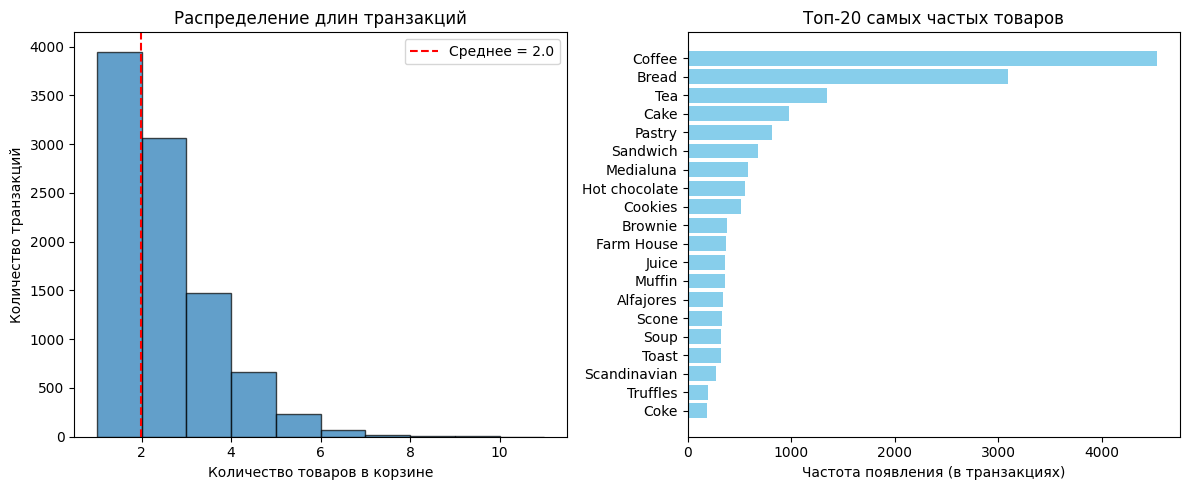

Информация об источнике данных
Название: The Bread Basket
Автор: Aditya Mittal (Kaggle)
Ссылка: https://www.kaggle.com/datasets/mittalvasu95/the-bread-basket
Контекст: Данные о заказах в пекарне 'The Bread Basket' в Эдинбурге
Период: с 26.01.2011 по 27.12.2003
Исходное количество записей: 20507
Колонки: Transaction, Item, date_time, period_day, weekday


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

df = pd.read_csv('data/bread basket.csv')
print("Исходные данные")
print(df.head())
print(f"\nРазмер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")
print(f"\nТипы данных:\n{df.dtypes}")
print(f"\nПроверка на пропуски:\n{df.isnull().sum()}")

# Удаляем строки с пропущенными знач
df_clean = df.dropna(subset=['Transaction', 'Item'])
print(f"\nПосле удаления пропусков: {df_clean.shape[0]} строк")

# Группируем по корзинам (транзакциям)
transactions_raw = df_clean.groupby('Transaction')['Item'].apply(list)

# Приводим к списку, где каждая транзакция — уникальные эл
transactions = [list(set(transaction)) for transaction in transactions_raw]

# Базов статистика
num_transactions = len(transactions)
unique_items = sorted(set(item for trans in transactions for item in trans))
num_unique_items = len(unique_items)
# Длины транзакций
transaction_lengths = [len(trans) for trans in transactions]
avg_length = np.mean(transaction_lengths)
median_length = np.median(transaction_lengths)
min_length = min(transaction_lengths)
max_length = max(transaction_lengths)

print("\nБазовая статистика:")
print(f"Количество транзакций (корзин): {num_transactions}")
print(f"Количество уникальных товаров: {num_unique_items}")
print(f"Средняя длина транзакции: {avg_length:.2f} товаров")
print(f"Медианная длина транзакции: {median_length:.0f} товаров")
print(f"Минимальная длина: {min_length}, максимальная: {max_length}")
# Процент транзакций с одним товаром
single_items_pct = (transaction_lengths.count(1) / num_transactions) * 100
print(f"Корзин из 1 товара: {single_items_pct:.1f}%")

# Распределение частот товаров
# Считаем, сколько раз каждый товар встречается во всех транзакциях
item_frequency = Counter()
for trans in transactions:
    item_frequency.update(trans)

# Преобразуем в DataFrame
freq_df = pd.DataFrame(item_frequency.items(), columns=['Item', 'Frequency'])
freq_df = freq_df.sort_values('Frequency', ascending=False).reset_index(drop=True)

print("\nРаспределение частот товаров(15 популярных):")
print(freq_df.head(15).to_string(index=False))

# Есть ли транзакции без товаров
empty_transactions = [i for i, trans in enumerate(transactions) if len(trans) == 0]
if empty_transactions:
    print(f"Внимание: {len(empty_transactions)} пустых транзакций!")

plt.figure(figsize=(12, 5))
# Гистограмма длин транзакций
plt.subplot(1, 2, 1)
plt.hist(transaction_lengths, bins=range(1, max_length + 2), edgecolor='black', alpha=0.7)
plt.title('Распределение длин транзакций', fontsize=12)
plt.xlabel('Количество товаров в корзине')
plt.ylabel('Количество транзакций')
plt.axvline(avg_length, color='red', linestyle='--', label=f'Среднее = {avg_length:.1f}')
plt.legend()

# Топ‑20 товаров по частоте
plt.subplot(1, 2, 2)
top20 = freq_df.head(20)
plt.barh(top20['Item'], top20['Frequency'], color='skyblue')
plt.title('Топ‑20 самых частых товаров', fontsize=12)
plt.xlabel('Частота появления (в транзакциях)')
plt.gca().invert_yaxis()  # инвертируем ось Y

plt.tight_layout()
plt.show()

print("Информация об источнике данных")
print("Название: The Bread Basket")
print("Автор: Aditya Mittal (Kaggle)")
print("Ссылка: https://www.kaggle.com/datasets/mittalvasu95/the-bread-basket")
print("Контекст: Данные о заказах в пекарне 'The Bread Basket' в Эдинбурге")
print("Период: с 26.01.2011 по 27.12.2003")
print("Исходное количество записей: 20507")
print("Колонки: Transaction, Item, date_time, period_day, weekday")

## **Задание 4. Эксперименты с параметрами и поиск правил**

Всего транзакций: 9465
Уникальных товаров: 94

Зависимость от min_suppor при min_confidence

min_support = 0.001 (абс. = 9 транз.)
  Apriori:  частых наборов =  471, время = 9.881 сек
  FP-Growth: частых наборов =  471, время = 0.056 сек
  Правил (conf>=0.5): Apriori=  56, FP=  56
  Правил (conf>=0.7): Apriori=  14, FP=  14
  Правил (conf>=0.9): Apriori=   0, FP=   0

min_support = 0.002 (абс. = 19 транз.)
  Apriori:  частых наборов =  260, время = 3.802 сек
  FP-Growth: частых наборов =  260, время = 0.050 сек
  Правил (conf>=0.5): Apriori=  21, FP=  21
  Правил (conf>=0.7): Apriori=   4, FP=   4
  Правил (conf>=0.9): Apriori=   0, FP=   0

min_support = 0.005 (абс. = 47 транз.)
  Apriori:  частых наборов =  114, время = 1.732 сек
  FP-Growth: частых наборов =  114, время = 0.075 сек
  Правил (conf>=0.5): Apriori=   5, FP=   5
  Правил (conf>=0.7): Apriori=   2, FP=   2
  Правил (conf>=0.9): Apriori=   0, FP=   0

min_support = 0.01 (абс. = 95 транз.)
  Apriori:  частых наборов =   61

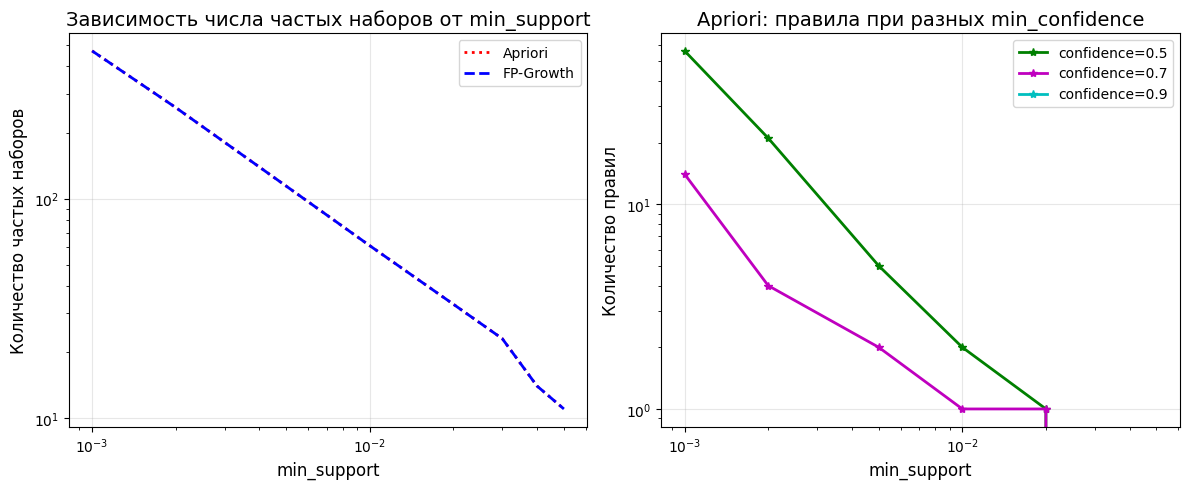


Таблица результатов
 min_support абс.порог  частые_Apriori  частые_FP  правила_Apriori_0.5  правила_FP_0.5  правила_Apriori_0.7  правила_FP_0.7  правила_Apriori_0.9  правила_FP_0.9  время_Apriori_сек  время_FP_сек
       0.001         9             471        471                   56              56                   14              14                    0               0              9.881         0.056
       0.002        19             260        260                   21              21                    4               4                    0               0              3.802         0.050
       0.005        47             114        114                    5               5                    2               2                    0               0              1.732         0.075
       0.010        95              61         61                    2               2                    1               1                    0               0              1.698         0.076
       0.

In [ ]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

print(f"Всего транзакций: {len(transactions)}")
print(f"Уникальных товаров: {len(set(item for trans in transactions for item in trans))}")

support_values = [0.001, 0.002, 0.005, 0.01, 0.02, 0.03, 0.04, 0.05]
confidence_values = [0.5, 0.7, 0.9]
min_lift = 1.2

# Словари для хранения результатов
results_apriori = {}      # {support: {'freq_count': n, 'rules_count': {conf: m}}}
results_fpgrowth = {}     # аналогично

# Для хранения времени выполнения
time_apriori = {}
time_fpgrowth = {}

print("\nЗависимость от min_suppor при min_confidence")

for min_support in support_values:
    print(f"\nmin_support = {min_support} (абс. = {min_support*len(transactions):.0f} транз.)")

    # Apriori
    start = time.time()
    freq_apriori = apriori(transactions, min_support)
    time_ap = time.time() - start
    time_apriori[min_support] = time_ap

    # Генерация правил для каждого min_confidence
    rules_by_conf_ap = {}
    for min_conf in confidence_values:
        rules = generate_rules(freq_apriori, min_conf, min_lift,
                               max_antecedent_len=3, max_consequent_len=1)
        rules_by_conf_ap[min_conf] = rules

    results_apriori[min_support] = {
        'freq_count': len(freq_apriori),
        'rules': rules_by_conf_ap
    }

    # FP-Growth
    start = time.time()
    tree, order = build_fp_tree(transactions, min_support, len(transactions))
    freq_fpgrowth = fpgrowth(tree, min_support, len(transactions))
    time_fp = time.time() - start
    time_fpgrowth[min_support] = time_fp

    rules_by_conf_fp = {}
    for min_conf in confidence_values:
        rules = generate_rules_fp(freq_fpgrowth, min_conf, min_lift,
                                   max_antecedent_len=3, max_consequent_len=1)
        rules_by_conf_fp[min_conf] = rules

    results_fpgrowth[min_support] = {
        'freq_count': len(freq_fpgrowth),
        'rules': rules_by_conf_fp
    }

    print(f"  Apriori:  частых наборов = {len(freq_apriori):4d}, время = {time_ap:.3f} сек")
    print(f"  FP-Growth: частых наборов = {len(freq_fpgrowth):4d}, время = {time_fp:.3f} сек")
    for mc in confidence_values:
        print(f"  Правил (conf>={mc}): Apriori={len(rules_by_conf_ap[mc]):4d}, FP={len(rules_by_conf_fp[mc]):4d}")

print("\nТОП-10 правил по лифту, уверенности и рычагу")

# Функция для форматирования вывода правил
def format_rule_row(antecedent, consequent, support, confidence, lift, leverage):
    ant_str = ', '.join(antecedent) if len(antecedent) <= 3 else ', '.join(antecedent[:3]) + '...'
    cons_str = ', '.join(consequent) if len(consequent) <= 3 else ', '.join(consequent[:3]) + '...'
    return f"{ant_str:25} -> {cons_str:10}  | sup={support:.4f} conf={confidence:.3f} lift={lift:.2f} lev={leverage:.6f}"

# Перебираем все комбинации параметров
for min_support in support_values:
    for min_confidence in confidence_values:
        print("-"*80)
        print(f"ПАРАМЕТРЫ: min_support = {min_support}, min_confidence = {min_confidence}, min_lift = {min_lift}")
        print(f"Количество транзакций: {len(transactions)}")

        # Получаем правила из FP-Growth
        rules = results_fpgrowth[min_support]['rules'][min_confidence]
        if len(rules) == 0:
            print("  Правила не найдены (возможно, слишком высокие пороги)")
            continue

        # Преобразуем в DataFrame для удобной сортировки
        rules_df = pd.DataFrame(rules, columns=['Antecedent', 'Consequent', 'Support', 'Confidence', 'Lift', 'Conviction', 'Leverage'])
        rules_df['Antecedent_str'] = rules_df['Antecedent'].apply(lambda x: ', '.join(x))
        rules_df['Consequent_str'] = rules_df['Consequent'].apply(lambda x: ', '.join(x))

        print("\n  Топ 10 по лифту:")
        top_lift = rules_df.nlargest(10, 'Lift')
        for idx, row in top_lift.iterrows():
            print(f"    {format_rule_row(row['Antecedent'], row['Consequent'], row['Support'], row['Confidence'], row['Lift'], row['Leverage'])}")

        print("\n  Топ 10 по уверенности:")
        top_conf = rules_df.nlargest(10, 'Confidence')
        for idx, row in top_conf.iterrows():
            print(f"    {format_rule_row(row['Antecedent'], row['Consequent'], row['Support'], row['Confidence'], row['Lift'], row['Leverage'])}")

        print("\n  Топ 10 по рычагу:")
        top_lev = rules_df.nlargest(10, 'Leverage')
        for idx, row in top_lev.iterrows():
            print(f"    {format_rule_row(row['Antecedent'], row['Consequent'], row['Support'], row['Confidence'], row['Lift'], row['Leverage'])}")

print("\nВизуализация зависимостей")

# Подготовка данных для графиков
supports = list(results_apriori.keys())
freq_ap = [results_apriori[s]['freq_count'] for s in supports]
freq_fp = [results_fpgrowth[s]['freq_count'] for s in supports]

# Для правил при разных min_confidence
rules_ap_05 = [len(results_apriori[s]['rules'][0.5]) for s in supports]
rules_ap_07 = [len(results_apriori[s]['rules'][0.7]) for s in supports]
rules_ap_09 = [len(results_apriori[s]['rules'][0.9]) for s in supports]

rules_fp_05 = [len(results_fpgrowth[s]['rules'][0.5]) for s in supports]
rules_fp_07 = [len(results_fpgrowth[s]['rules'][0.7]) for s in supports]
rules_fp_09 = [len(results_fpgrowth[s]['rules'][0.9]) for s in supports]

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
# Частые наборы (Apriori/FP-Growth)
plt.plot(supports, freq_ap, color='red', linestyle=':', label='Apriori', linewidth=2, markersize=6)
plt.plot(supports, freq_fp, color='blue', linestyle='--', label='FP-Growth', linewidth=2, markersize=8)
plt.xlabel('min_support', fontsize=12)
plt.ylabel('Количество частых наборов', fontsize=12)
plt.title('Зависимость числа частых наборов от min_support', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xscale('log')
plt.yscale('log')

# Количество правил (Apriori, разные confidence)
plt.subplot(1, 2, 2)
plt.plot(supports, rules_ap_05, 'g*-', label='confidence=0.5', linewidth=2)
plt.plot(supports, rules_ap_07, 'm*-', label='confidence=0.7', linewidth=2)
plt.plot(supports, rules_ap_09, 'c*-', label='confidence=0.9', linewidth=2)
plt.xlabel('min_support', fontsize=12)
plt.ylabel('Количество правил', fontsize=12)
plt.title('Apriori: правила при разных min_confidence', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xscale('log')
plt.yscale('log')
plt.tight_layout()
plt.show()


print("\nТаблица результатов")
summary_data = []
for s in supports:
    row = {
        'min_support': s,
        'абс.порог': f"{s*len(transactions):.0f}",
        'частые_Apriori': results_apriori[s]['freq_count'],
        'частые_FP': results_fpgrowth[s]['freq_count'],
    }
    # Добавляем количество правил для каждого min_confidence
    for mc in confidence_values:
        row[f'правила_Apriori_{mc}'] = len(results_apriori[s]['rules'][mc])
        row[f'правила_FP_{mc}'] = len(results_fpgrowth[s]['rules'][mc])
    row['время_Apriori_сек'] = round(time_apriori[s], 3)
    row['время_FP_сек'] = round(time_fpgrowth[s], 3)
    summary_data.append(row)

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))


## **Задание 5. Сравнение производительности Apriori и FP‑Growth**

In [ ]:
import time
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

def generate_synthetic_transactions(num_transactions, avg_items_per_trans, num_unique_items=100, zipf_alpha=1.2):
    """
    - num_transactions: количество транзакций
    - avg_items_per_trans: среднее количество элементов в транзакции
    - num_unique_items: количество уникальных товаров - 100
    - zipf_alpha: параметр Ципфа (чем больше, тем популярнее топ-товары)
    Возвращает:
    - transactions: список списков (каждая транзакция — список элементов)
    """
    # Вероятности для товаров по закону Ципфа
    probabilities = np.array([1.0 / (i+1)**zipf_alpha for i in range(num_unique_items)])
    probabilities /= probabilities.sum()

    transactions = []
    for _ in range(num_transactions):
        # Длина транзакции по распределению Пуассона
        trans_len = max(1, min(30, int(np.random.poisson(avg_items_per_trans))))
        # Выбираем товары без повторений
        items_idx = np.random.choice(num_unique_items, size=trans_len,
                                     replace=False, p=probabilities)
        transaction = [f"Item_{i}" for i in items_idx]
        transactions.append(transaction)

    return transactions

transactions_counts = [1000, 5000, 10000, 20000, 50000]
avg_items_list = [5, 10]
fixed_min_support = 0.01  # Фиксированная мин поддержка
NUM_UNIQUE_ITEMS = 100 #уникальн товары

print("Параметры эксперемента:")
print(f"  - Количество транзакций: {transactions_counts}")
print(f"  - Средняя длина транзакции: {avg_items_list}")
print(f"  - Минимальная поддержка: {fixed_min_support}")
print(f"  - Уникальных товаров: {NUM_UNIQUE_ITEMS}")

results = {}

for avg_len in avg_items_list:
    print(f"\nЭКСПЕРИМЕНТ: Средняя длина транзакции = {avg_len}")

    results[avg_len] = {}

    for num_trans in transactions_counts:
        print(f"\n--- Тест: {num_trans} транзакций, ср.длина = {avg_len} ---")

        # Генерируем данные
        transactions = generate_synthetic_transactions(
            num_transactions=num_trans,
            avg_items_per_trans=avg_len,
            num_unique_items=NUM_UNIQUE_ITEMS,
            zipf_alpha=1.2
        )

        # Статистика сгенерированных данных
        all_items = [item for trans in transactions for item in trans]
        unique_items = len(set(all_items))
        actual_avg_len = np.mean([len(trans) for trans in transactions])
        print(f"  Фактическая средняя длина: {actual_avg_len:.2f}, уникальных товаров: {unique_items}")

        # === Apriori ===
        start = time.time()
        freq_apriori = apriori(transactions, fixed_min_support)
        time_ap = time.time() - start
        print(f"  Apriori:    время = {time_ap:.4f} сек, частых наборов = {len(freq_apriori)}")

        # === FP-Growth ===
        start = time.time()
        tree, order = build_fp_tree(transactions, fixed_min_support, len(transactions))
        freq_fpgrowth = fpgrowth(tree, fixed_min_support, len(transactions))
        time_fp = time.time() - start
        print(f"  FP-Growth:  время = {time_fp:.4f} сек, частых наборов = {len(freq_fpgrowth)}")

        # Сохраняем результаты
        results[avg_len][num_trans] = {
            'apriori_time': time_ap,
            'fpgrowth_time': time_fp,
            'apriori_freq_count': len(freq_apriori),
            'fpgrowth_freq_count': len(freq_fpgrowth)
        }

Параметры эксперемента:
  - Количество транзакций: [1000, 5000, 10000, 20000, 50000]
  - Средняя длина транзакции: [5, 10]
  - Минимальная поддержка: 0.01
  - Уникальных товаров: 100

ЭКСПЕРИМЕНТ: Средняя длина транзакции = 5

--- Тест: 1000 транзакций, ср.длина = 5 ---
  Фактическая средняя длина: 4.89, уникальных товаров: 100
  Apriori:    время = 1.6569 сек, частых наборов = 611
  FP-Growth:  время = 0.0308 сек, частых наборов = 611

--- Тест: 5000 транзакций, ср.длина = 5 ---
  Фактическая средняя длина: 5.02, уникальных товаров: 100
  Apriori:    время = 7.6257 сек, частых наборов = 616
  FP-Growth:  время = 0.1576 сек, частых наборов = 616

--- Тест: 10000 транзакций, ср.длина = 5 ---
  Фактическая средняя длина: 5.01, уникальных товаров: 100
  Apriori:    время = 17.2778 сек, частых наборов = 597
  FP-Growth:  время = 0.4973 сек, частых наборов = 597

--- Тест: 20000 транзакций, ср.длина = 5 ---
  Фактическая средняя длина: 5.02, уникальных товаров: 100
  Apriori:    время = 35.


Графики зависимости


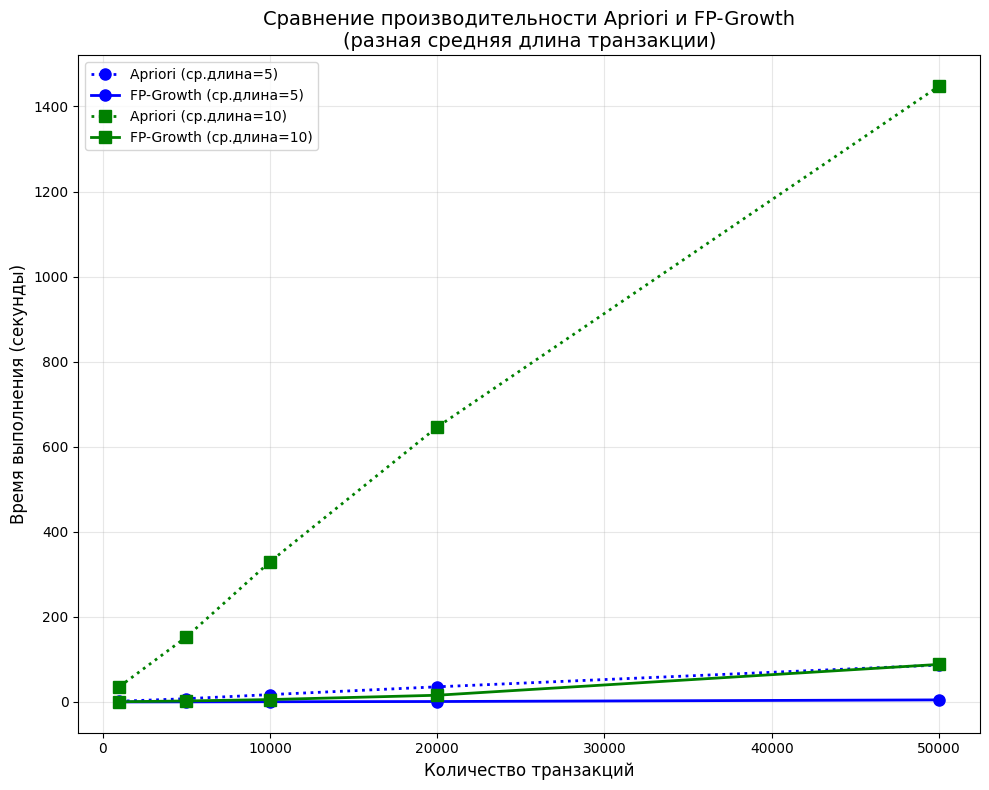

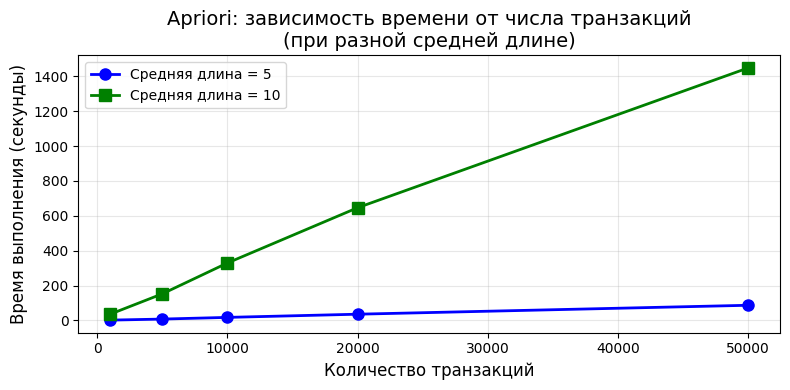

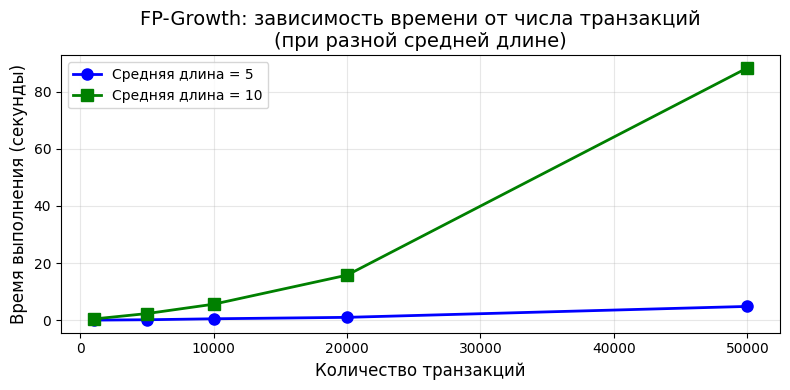


Таблица результатов
------------------------------------------------------------------------------------------
Транзакций|  Ср.длина|    Apriori (сек)|  FP-Growth (сек)| Ускорение|   Частых наборов
------------------------------------------------------------------------------------------
1000         5            1.6569          0.0308           53.78        611         
5000         5            7.6257          0.1576           48.38        616         
10000        5            17.2778         0.4973           34.74        597         
20000        5            35.5727         1.0009           35.54        599         
50000        5            86.7750         4.8242           17.99        601         
1000         10           35.9259         0.4267           84.19        13188       
5000         10           152.4946        2.3187           65.77        11783       
10000        10           329.3975        5.6031           58.79        11436       
20000        10           646.

In [ ]:
print("\nГрафики зависимости")

colors = {5: 'blue', 10: 'green'}
markers = {5: 'o', 10: 's'}

# 1: Сравнение Apriori и FP-Growth для разных средних длин
plt.figure(figsize=(10, 8))

for avg_len in avg_items_list:
    times_ap = []
    times_fp = []
    trans_list = []

    for num_trans in transactions_counts:
        if num_trans in results[avg_len]:
            times_ap.append(results[avg_len][num_trans]['apriori_time'])
            times_fp.append(results[avg_len][num_trans]['fpgrowth_time'])
            trans_list.append(num_trans)

    # Apriori (штриховые линии)
    plt.plot(trans_list, times_ap, color=colors[avg_len], linestyle=':', marker=markers[avg_len],
             linewidth=2, markersize=8, label=f'Apriori (ср.длина={avg_len})')

    # FP-Growth (сплошные линии)
    plt.plot(trans_list, times_fp, color=colors[avg_len], linestyle='-', marker=markers[avg_len],
             linewidth=2, markersize=8, label=f'FP-Growth (ср.длина={avg_len})')

plt.xlabel('Количество транзакций', fontsize=12)
plt.ylabel('Время выполнения (секунды)', fontsize=12)
plt.title('Сравнение производительности Apriori и FP-Growth\n(разная средняя длина транзакции)', fontsize=14)
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2: Только Apriori
plt.figure(figsize=(8, 4))

for avg_len in avg_items_list:
    times_ap = []
    trans_list = []

    for num_trans in transactions_counts:
        if num_trans in results[avg_len]:
            times_ap.append(results[avg_len][num_trans]['apriori_time'])
            trans_list.append(num_trans)

    plt.plot(trans_list, times_ap, color=colors[avg_len], marker=markers[avg_len], linewidth=2, markersize=8,
             label=f'Средняя длина = {avg_len}')

plt.xlabel('Количество транзакций', fontsize=12)
plt.ylabel('Время выполнения (секунды)', fontsize=12)
plt.title('Apriori: зависимость времени от числа транзакций\n(при разной средней длине)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 3: Только FP-Growth
plt.figure(figsize=(8, 4))

for avg_len in avg_items_list:
    times_fp = []
    trans_list = []

    for num_trans in transactions_counts:
        if num_trans in results[avg_len]:
            times_fp.append(results[avg_len][num_trans]['fpgrowth_time'])
            trans_list.append(num_trans)

    plt.plot(trans_list, times_fp, color=colors[avg_len], marker=markers[avg_len], linewidth=2, markersize=8,
             label=f'Средняя длина = {avg_len}')

plt.xlabel('Количество транзакций', fontsize=12)
plt.ylabel('Время выполнения (секунды)', fontsize=12)
plt.title('FP-Growth: зависимость времени от числа транзакций\n(при разной средней длине)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nТаблица результатов")
print("-"*90)
print("{:<12} {:<12} {:<15} {:<16} {:<12} {:<12}".format(
    "Транзакций|", "Ср.длина|", "Apriori (сек)|", "FP-Growth (сек)|", "Ускорение|", "Частых наборов"))
print("-"*90)

for avg_len in avg_items_list:
    for num_trans in transactions_counts:
        if num_trans in results[avg_len]:
            ap_time = results[avg_len][num_trans]['apriori_time']
            fp_time = results[avg_len][num_trans]['fpgrowth_time']
            speedup = ap_time / fp_time if fp_time > 0 else 0
            freq_cnt = results[avg_len][num_trans]['apriori_freq_count']

            print("{:<12} {:<12} {:<15.4f} {:<16.4f} {:<12.2f} {:<12}".format(
                num_trans, avg_len, ap_time, fp_time, speedup, freq_cnt))


**Основные наблюдения по результатам:**  
* FP‑Growth значительно быстрее Apriori во всех сценариях(ускорение от 16× до 84×)
* С ростом числа транзакций относительное ускорение снижается

**Влияние числа транзакций:**
* Время работы обоих алгоритмов растёт с увеличением N
* Для Apriori рост близок к линейному при средней длине транзакции 5, но становится более резким при длине 10
* FP‑Growth демонстрирует более плавный рост времени выполнения: при длине 5 — почти линейный, при длине 10 — умеренно суперлинейный

**Влияние средней длины транзакции:**
* Увеличение средней длины с 5 до 10 резко увеличивает время выполнения обоих алгоритмов
* Эффект сильнее для Apriori: например, при N=50000 время возрастает с 86,78с до 1447,82с
* Для FP‑Growth рост тоже заметен, но менее печален: с 4,82с до 88,27с при N=50000

**Объяснение различий с точки зрения вычислительной сложности**:  
*Apriori:*  
Сложность: O(2^d*N), где d - число уникальных элементов, N - число транзакций.
* Множественные проходы по данным: на каждой итерации k алгоритм сканирует все транзакции для подсчёта поддержки кандидатов размера k
* Генерация кандидатов: экспоненциальный рост числа кандидатов при увеличении длины наборов и плотности данных (длина транзакции 10)
* Избыточные вычисления: проверка всех подмножеств, даже если они заведомо не будут частыми
* Высокая чувствительность к длине транзакций

*FP-Growth:*  
Сложность: O(N*d+|F|), где |F| - размер множества частых наборов.
* Однократный проход для построения FP-дерева: данные сжимаются в компактную структуру, отражающую частоту и связи между элементами
* Отсутствие генерации кандидатов: частые наборы извлекаются рекурсивно из дерева без явного перебора всех возможных комбинаций
* Эффективная обработка длинных транзакций: дерево позволяет агрегировать информацию о частых паттернах, снижая необходимость многократного сканирования данных
* Локальность вычислений: условные базы строятся только для релевантных подмножеств, что сокращает объём обрабатываемых данных на рекурсивных шагах

**Выводы:**  
1. FP-Growth предпочтительнее для больших наборов данных: его сложность линейна по N и слабо зависит от длины транзакций, что делает его масштабируемым.
2. Apriori подходит для малых или разреженных данных: при N<5000 и короткой длине транзакций он может быть приемлем, но быстро теряет эффективность.


## **Задание 6. Визуализация ассоциативных правил**

Загружено правил из results_fpgrowth: 21

Топ 20 интересеных правил:
1. Toast           → Coffee    
   Support: 0.0237 | Conf: 0.704 | Lift: 1.472 | Score: 0.1596

2. Keeping It Local → Coffee    
   Support: 0.0054 | Conf: 0.810 | Lift: 1.692 | Score: 0.1006

3. Extra Salami or Feta → Coffee    
   Support: 0.0033 | Conf: 0.816 | Lift: 1.705 | Score: 0.0796

4. Spanish Brunch  → Coffee    
   Support: 0.0109 | Conf: 0.599 | Lift: 1.252 | Score: 0.0782

5. Salad           → Coffee    
   Support: 0.0066 | Conf: 0.626 | Lift: 1.309 | Score: 0.0664

6. Cake, Sandwich  → Coffee    
   Support: 0.0046 | Conf: 0.677 | Lift: 1.415 | Score: 0.0653

7. Cake, Hot chocolate → Coffee    
   Support: 0.0069 | Conf: 0.602 | Lift: 1.258 | Score: 0.0627

8. Hot chocolate, Pastry → Coffee    
   Support: 0.0038 | Conf: 0.667 | Lift: 1.394 | Score: 0.0573

9. Sandwich, Soup  → Coffee    
   Support: 0.0036 | Conf: 0.654 | Lift: 1.367 | Score: 0.0536

10. Art Tray        → Coffee    
   Support: 0.0027

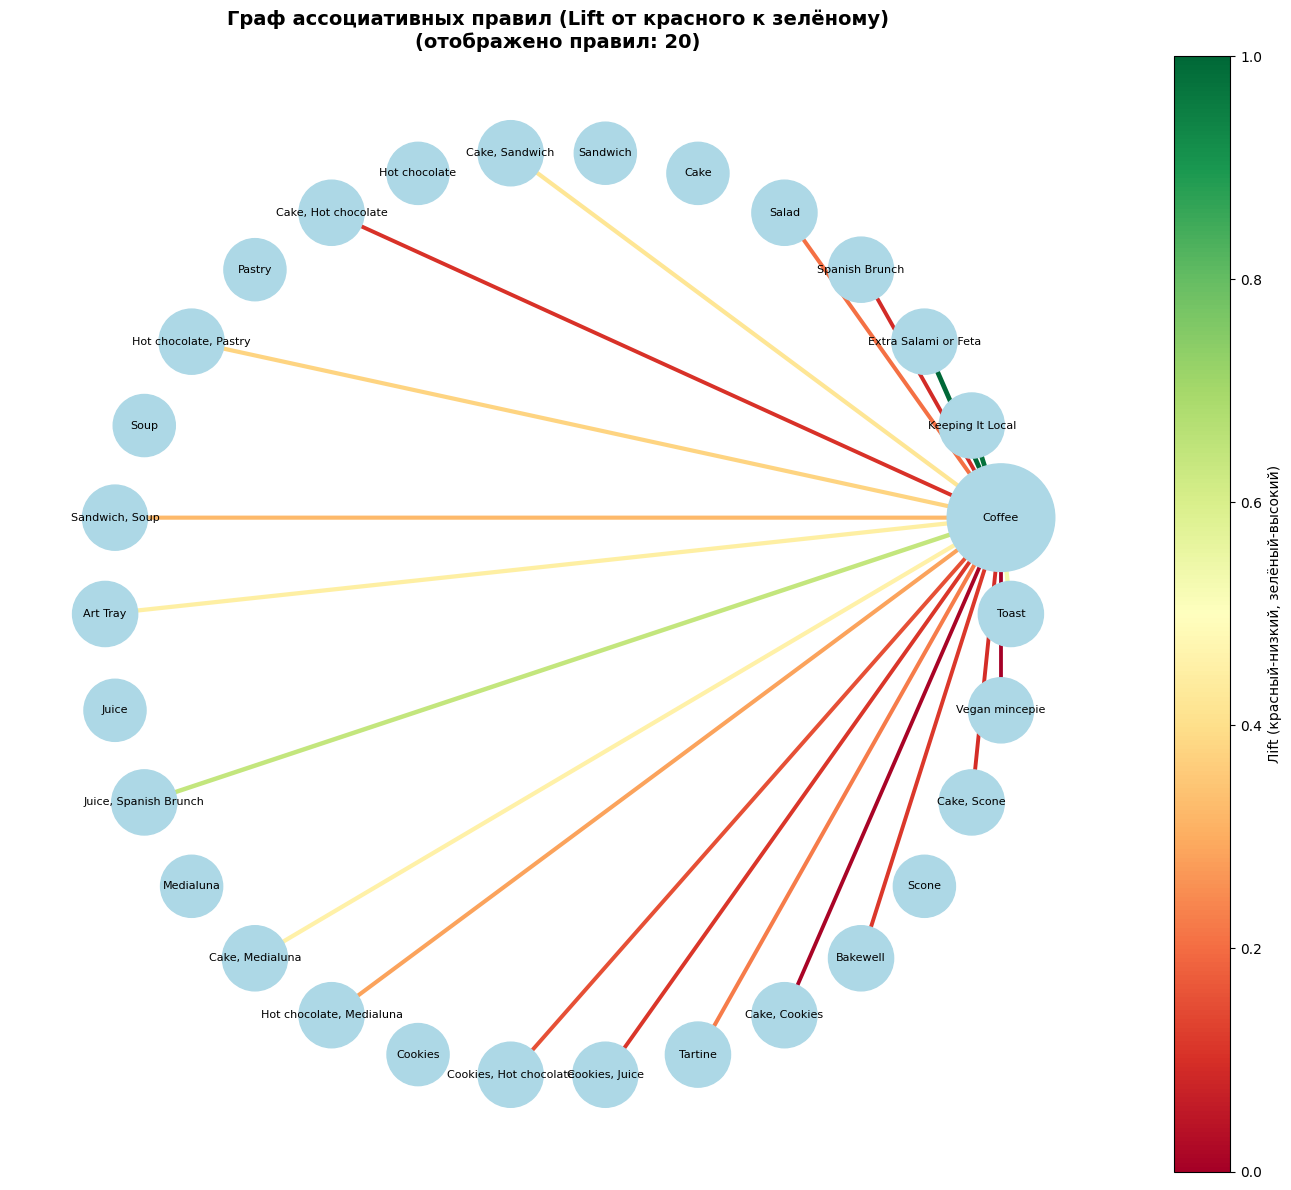

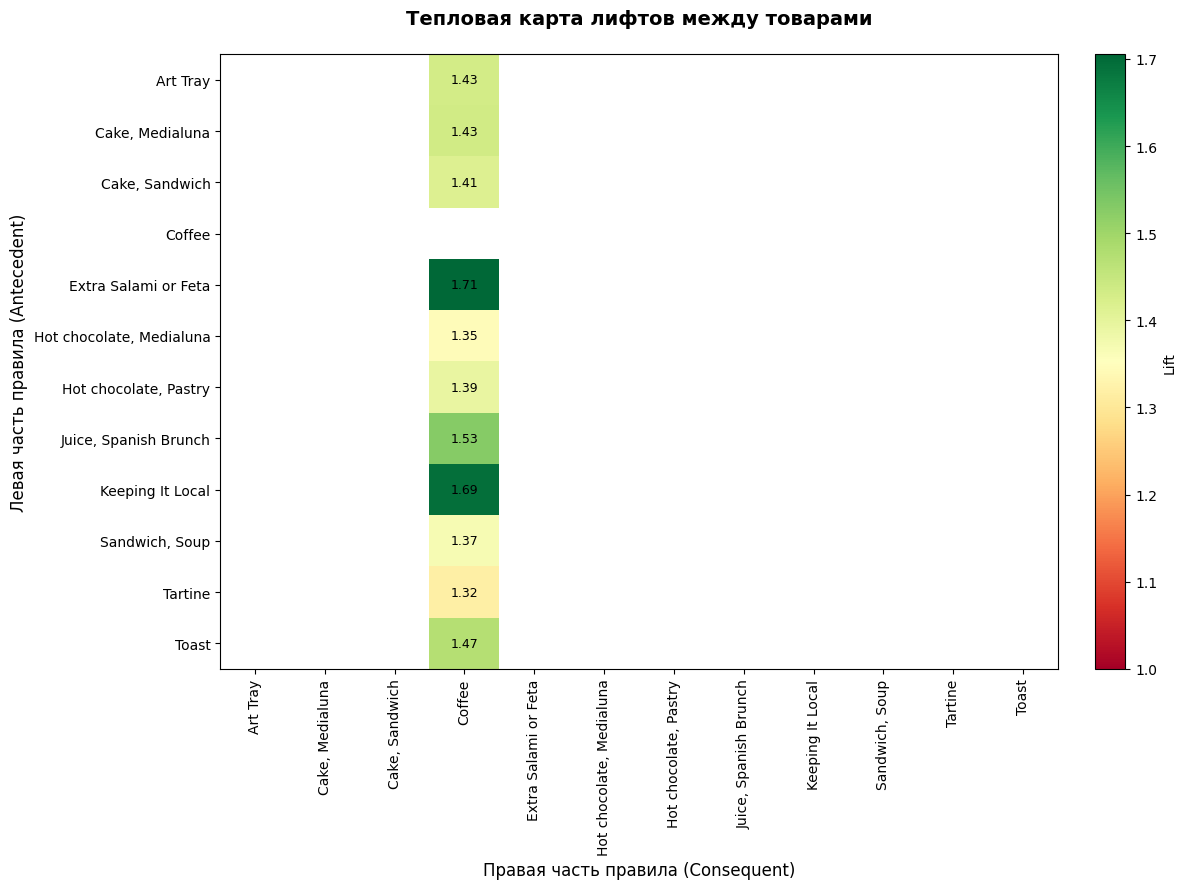

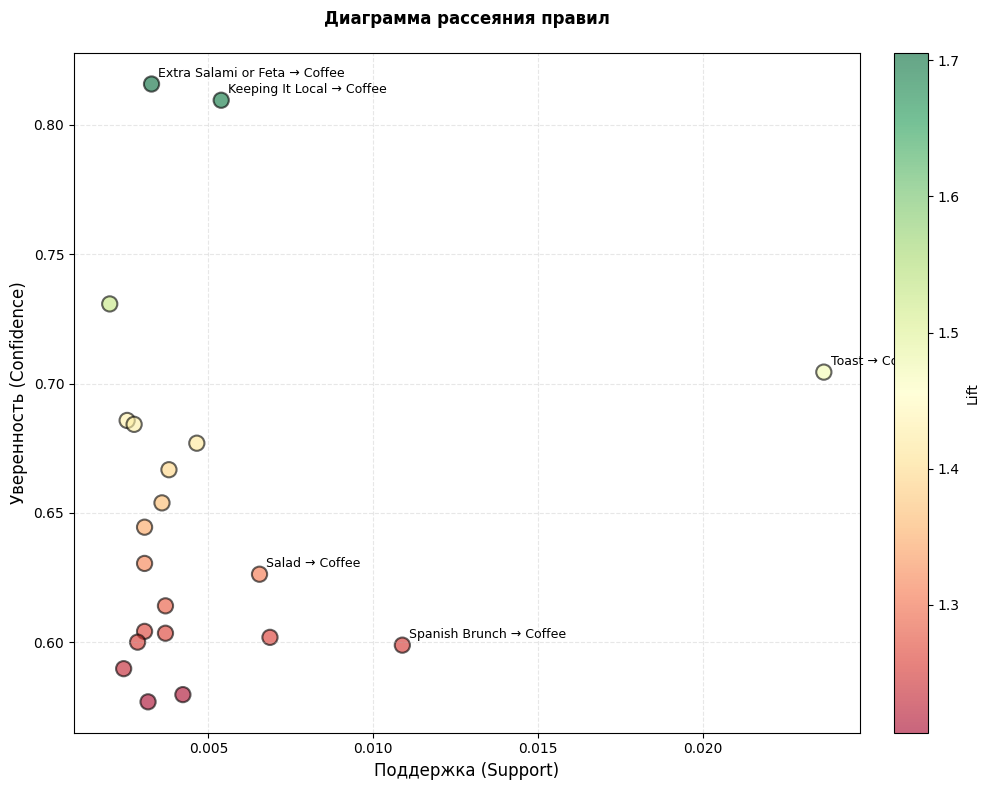


Топ-5 интересных правил(по комбинир score):

4. Toast → Coffee
   Support: 0.0237 | Confidence: 0.704 | Lift: 1.47
   Interest Score: 0.1596

2. Keeping It Local → Coffee
   Support: 0.0054 | Confidence: 0.810 | Lift: 1.69
   Interest Score: 0.1006

1. Extra Salami or Feta → Coffee
   Support: 0.0033 | Confidence: 0.816 | Lift: 1.71
   Interest Score: 0.0796

18. Spanish Brunch → Coffee
   Support: 0.0109 | Confidence: 0.599 | Lift: 1.25
   Interest Score: 0.0782

12. Salad → Coffee
   Support: 0.0066 | Confidence: 0.626 | Lift: 1.31
   Interest Score: 0.0664


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

def get_most_interesting_rules(rules_df, top_n=30):
    """
    Отбор наиболее интересных правил по комбинированному критерию:
    Interest Score = Lift * Confidence * sqrt(Support)
    - rules_df: DataFrame с колонками ['Antecedent', 'Consequent', 'Support', 'Confidence', 'Lift', ...]
    - top_n: сколько правил отобрать
    """
    rules_df = rules_df.copy()
    # Добавляем колонку с комбинированным score
    rules_df['InterestScore'] = rules_df['Lift'] * rules_df['Confidence'] * np.sqrt(rules_df['Support'])
    # Сортируем по убыванию
    rules_df_sorted = rules_df.sort_values('InterestScore', ascending=False).reset_index(drop=True)
    return rules_df_sorted.head(top_n), len(rules_df), top_n


def build_association_graph(rules_df, max_rules=25):
    """
    Построение направленного графа ассоциаций.
    Узлы - товары. Рёбра - правила (от Antecedent к Consequent).
    Цвет ребра отражает lift (красный -> низкий, зелёный -> высокий).
    Толщина ребра пропорциональна уверенности.
    """
    G = nx.DiGraph()

    # Нормализуем lift для градиента цвета
    min_lift = rules_df['Lift'].min()
    max_lift = rules_df['Lift'].max()

    for idx, row in rules_df.head(max_rules).iterrows():
        ant = row['Antecedent']
        cons = row['Consequent']
        lift = row['Lift']
        confidence = row['Confidence']
        support = row['Support']

        # Преобразуем в строки для отображения
        if isinstance(ant, tuple):
            ant_str = ', '.join(ant)
            for item in ant:
                G.add_node(item)
        else:
            ant_str = ant
            G.add_node(ant)

        if isinstance(cons, tuple):
            cons_str = ', '.join(cons)
            for item in cons:
                G.add_node(item)
        else:
            cons_str = cons
            G.add_node(cons)

        # Нормируем lift для цвета (от 0 до 1, красный-зелёный)
        norm_lift = (lift - min_lift) / (max_lift - min_lift) if max_lift > min_lift else 0.5

        # Добавляем ребро с атрибутами
        G.add_edge(ant_str, cons_str,
                   weight=confidence,  # толщина по уверенности
                   lift=lift,
                   norm_lift=norm_lift,
                   support=support,
                   label=f"lift={lift:.2f}\nconf={confidence:.2f}")

    return G, len(rules_df.head(max_rules))


def visualize_association_graph(G, num_rules_used, title_prefix="Граф ассоциативных правил"):
    """
    Визуализация графа с помощью matplotlib и networkx.
    Узлы расположены по кругу для лучшей читаемости.
    """
    plt.figure(figsize=(14, 12))
    # Используем круговое расположение узлов для аккуратности
    pos = nx.circular_layout(G)

    # Веса рёбер для толщины (нормируем от 1 до 5)
    weights = []
    colors = []
    edge_labels = {}

    for u, v, data in G.edges(data=True):
        # Толщина по уверенности (от 1 до 4)
        thickness = 1 + data['weight'] * 3
        weights.append(thickness)
        # Цвет по лифту (красный->низкий, зелёный->высокий)
        colors.append(data['norm_lift'])

    # Рисуем узлы
    node_sizes = [2000 + G.degree(node) * 200 for node in G.nodes()]
    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='lightblue')

    # Рисуем рёбра с цветом от красного к зелёному
    edges = nx.draw_networkx_edges(G, pos,
                                  edge_color=colors,
                                  edge_cmap=plt.cm.RdYlGn,
                                  width=weights,
                                  edge_vmin=0, edge_vmax=1,
                                  arrows=True,
                                  arrowsize=20,
                                  arrowstyle='->',
                                  min_source_margin=15,
                                  min_target_margin=15)

    # Рисуем подписи узлов
    labels = {node: node for node in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels, font_size=8, font_weight='normal')

    # Добавляем цветовую шкалу для лифта
    sm = plt.cm.ScalarMappable(cmap=plt.cm.RdYlGn, norm=plt.Normalize(0, 1))
    sm.set_array([])
    cbar = plt.colorbar(sm, label='Лift (красный-низкий, зелёный-высокий)', ax=plt.gca())

    plt.title(f"{title_prefix}\n(отображено правил: {num_rules_used})",
              fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()


def plot_lift_heatmap(rules_df, top_items=15):
    """
    Построение тепловой карты (heatmap) лифтов для пар элементов.
    С числовыми значениями в каждой ячейке.
    Берём top_items самых частых товаров и строим матрицу lift'ов.
    """
    # Собираем все пары (antecedent, consequent)
    pairs = []
    lift_values = []

    for idx, row in rules_df.iterrows():
        ant = row['Antecedent']
        cons = row['Consequent']
        # Преобразуем в строки, если это кортежи
        if isinstance(ant, tuple):
            ant_str = ', '.join(ant)
        else:
            ant_str = ant

        if isinstance(cons, tuple):
            cons_str = ', '.join(cons)
        else:
            cons_str = cons

        pairs.append((ant_str, cons_str))
        lift_values.append(row['Lift'])

    # Находим все уникальные товары
    items = set()
    for a, c in pairs:
        items.add(a)
        items.add(c)

    # Если товаров слишком много, берём только top_items самых частых в правилах
    if len(items) > top_items:
        # Считаем частоту появления товаров в правилах
        item_counter = Counter()
        for a, c in pairs:
            item_counter[a] += 1
            item_counter[c] += 1
        most_common = [item for item, _ in item_counter.most_common(top_items)]
        items = set(most_common)

    items = sorted(items)
    n = len(items)
    index_map = {item: i for i, item in enumerate(items)}

    # Инициализируем матрицу лифтов NaN
    lift_matrix = np.full((n, n), np.nan)

    for (a, c), lift in zip(pairs, lift_values):
        if a in index_map and c in index_map:
            lift_matrix[index_map[a], index_map[c]] = lift

    # Строим тепловую карту с числами
    plt.figure(figsize=(12, 9))
    # Маска для NaN значений
    masked_matrix = np.ma.masked_where(np.isnan(lift_matrix), lift_matrix)

    im = plt.imshow(masked_matrix, cmap='RdYlGn', aspect='auto',
                    vmin=1, vmax=max(lift_values) if lift_values else 2,
                    interpolation='nearest')

    plt.colorbar(im, label='Lift', fraction=0.046, pad=0.04)

    # Добавляем числовые значения в ячейки
    for i in range(n):
        for j in range(n):
            if not np.isnan(lift_matrix[i, j]):
                text_color = 'black' if lift_matrix[i, j] < 2 else 'white'
                plt.text(j, i, f'{lift_matrix[i, j]:.2f}',
                        ha='center', va='center',
                        color=text_color, fontsize=9)

    plt.xticks(range(n), items, rotation=90, fontsize=10)
    plt.yticks(range(n), items, fontsize=10)
    plt.xlabel("Правая часть правила (Consequent)", fontsize=12)
    plt.ylabel("Левая часть правила (Antecedent)", fontsize=12)
    plt.title(f"Тепловая карта лифтов между товарами\n",
              fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


def plot_support_confidence_scatter(rules_df, min_lift_threshold=1.2):
    """
    Диаграмма рассеяния: Support (x) vs Confidence (y).
    Цвет точек — Lift.
    """
    # Фильтруем правила с достаточно высоким лифтом
    filtered_df = rules_df[rules_df['Lift'] >= min_lift_threshold].copy()

    if filtered_df.empty:
        print(f"Нет правил с Lift >= {min_lift_threshold}")
        return

    # InterestScore для отбора топ-5
    filtered_df['InterestScore'] = filtered_df['Lift'] * filtered_df['Confidence'] * np.sqrt(filtered_df['Support'])
    top5 = filtered_df.nlargest(5, 'InterestScore')

    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(filtered_df['Support'], filtered_df['Confidence'],
                         c=filtered_df['Lift'], cmap='RdYlGn', s=120, alpha=0.6, edgecolors='black', linewidth=1.5)

    # Добавляем цветовую шкалу
    cbar = plt.colorbar(scatter, label='Lift', fraction=0.046, pad=0.04)

    plt.xlabel('Поддержка (Support)', fontsize=12)
    plt.ylabel('Уверенность (Confidence)', fontsize=12)
    plt.title(f'Диаграмма рассеяния правил\n', fontsize=12, fontweight='bold')
    plt.grid(True, alpha=0.3, linestyle='--')

    # Отмечаем топ-5 правил
    for idx, row in top5.iterrows():
        ant_str = ', '.join(row['Antecedent']) if isinstance(row['Antecedent'], tuple) else row['Antecedent']
        cons_str = ', '.join(row['Consequent']) if isinstance(row['Consequent'], tuple) else row['Consequent']

        # Добавляем подпись
        label = f"{ant_str} → {cons_str}"
        plt.annotate(label, (row['Support'], row['Confidence']),
                    fontsize=9, xytext=(5, 5), textcoords='offset points')
    plt.tight_layout()
    plt.show()

    print("\nТоп-5 интересных правил(по комбинир score):")
    for idx, row in top5.iterrows():
        ant_str = ', '.join(row['Antecedent']) if isinstance(row['Antecedent'], tuple) else row['Antecedent']
        cons_str = ', '.join(row['Consequent']) if isinstance(row['Consequent'], tuple) else row['Consequent']
        print(f"\n{idx+1}. {ant_str} → {cons_str}")
        print(f"   Support: {row['Support']:.4f} | Confidence: {row['Confidence']:.3f} | Lift: {row['Lift']:.2f}")
        print(f"   Interest Score: {row['InterestScore']:.4f}")

min_sup_val = 0.002
min_conf_val = 0.5
rules = results_fpgrowth[min_sup_val]['rules'][min_conf_val]
rules_df = pd.DataFrame(rules, columns=['Antecedent', 'Consequent', 'Support', 'Confidence', 'Lift', 'Conviction', 'Leverage'])
print(f"Загружено правил из results_fpgrowth: {len(rules_df)}")

# Отбираем наиболее интересные правила
interesting_rules, total_rules, displayed_rules = get_most_interesting_rules(rules_df, top_n=20)
print("\nТоп 20 интересеных правил:")
for idx, row in interesting_rules.head(20).iterrows():
    ant_str = ', '.join(row['Antecedent']) if isinstance(row['Antecedent'], tuple) else row['Antecedent']
    cons_str = ', '.join(row['Consequent']) if isinstance(row['Consequent'], tuple) else row['Consequent']
    print(f"{idx+1}. {ant_str:15} → {cons_str:10}")
    print(f"   Support: {row['Support']:.4f} | Conf: {row['Confidence']:.3f} | Lift: {row['Lift']:.3f} | Score: {row['InterestScore']:.4f}")
    print()

print("\nВИЗУАЛИЗАЦИИ:")

G, num_rules_in_graph = build_association_graph(interesting_rules, max_rules=20)
visualize_association_graph(G, num_rules_in_graph,
                           title_prefix=f"Граф ассоциативных правил (Lift от красного к зелёному)")

# Тепловая карта лифтов с числами
plot_lift_heatmap(rules_df, top_items=12)

# Диаграмма рассеяния с отмеченными топ-5 правилами
plot_support_confidence_scatter(rules_df, min_lift_threshold=1.2)

## **Задание 7. Интерпретация результатов**

### 1. Какие товары покупают вместе?
Кофе (Coffee) является ключевым товар, который часто покупают вместе с другими позициями меню. Наиболее интересные комбинации:  
* Toast → Coffee (Support = 0.0237, Lift = 1.472) — самая популярная пара. Тосты часто заказывают с кофе, что логично с точки зрения формата завтрака/перекуса.
* Keeping It Local → Coffee (Lift = 1.692) — локальные позиции меню хорошо «тянут» за собой кофе.
* Extra Salami or Feta → Coffee (Lift = 1.705) — покупатели, берущие мясные/сырные позиции, также склонны заказывать кофе.
* Spanish Brunch → Coffee (Lift = 1.252) — поздний завтрак хорошо коррелирует с потреблением кофе.
* Салаты и десерты (Cake, Sandwich, Hot chocolate, Pastry и др.) → Coffee — кофе служит «дополнением» к основным позициям меню.

### 2. Правила для рекомендаций и перекрёстных продаж
1. На кассе/в интерфейсе заказа предлагать кофе как дополнение к тостам, сэндвичам, десертам.
2. Разместить кофемашину рядом с зоной выдачи тостов/сэндвичей — это усилит импульсные покупки.
3. Промо-акции(например, «Тост + кофе по специальной цене»).
4. В меню, выделить блоки «идеальные пары» (например, «Spanish Brunch с кофе»).
5. Персонализация: если клиент добавил в корзину салат или десерт — автоматически предложить кофе.

### 3. Почему некоторые правила могут быть бесполезными
* Тривиальные/очевидные правила:  
`Toast → Coffee` — хотя Lift высокий, связь предсказуема (тосты + кофе — классический завтрак). Такие правила полезны для автоматизации, но не открывают новых инсайтов.  

* Правила с низкой поддержкой (Support):
`Keeping It Local → Coffee` (Support = 0.0054) — комбинация встречается редко. Внедрение акций на основе такого правила не принесёт масштабного эффекта, так как затрагивает узкую группу клиентов.
`Juice, Spanish Brunch → Coffee` (Support = 0.0020) — слишком низкая частота для массовых рекомендаций.

* Правила с редкими товарами:  
Если нишевый продукт (например, Vegan mincepie), даже при высоком Lift (1.206) эффект от перекрёстных продаж будет минимальным из-за ограниченного спроса.
Такие правила полезны только для персонализированных рекомендаций (например, в чат-боте при заказе конкретного десерта).

* Балансировка Lift и Support:  
Высокий Lift при низком Support (например, Extra Salami or Feta → Coffee) сигнализирует о «скрытой» корреляции, но с малым объёмом транзакций. Это может быть стартовой точкой для тестирования новых акций, но не для масштабных изменений в ассортименте/размещении.


###Выводы:
* Фокус на правилах с высоким Lift и Support (например, Toast → Coffee) - основа для стандартных рекомендаций.
* Правила с высоким Lift, но низким Support - потенциал для A/B-тестирования и персонализации.
* Избегать переоценки тривиальных связей - они подтверждены данными, но не дают новых возможностей для роста.
* Учитывать специфику ассортимента - редкие товары требуют иных подходов (микросегментация, специальные предложения).